In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/test.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [20]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [21]:
df.drop(columns=["Unnamed: 0", "id"], inplace=True)

In [22]:
df.isna().sum()

Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [23]:
df.dropna(inplace=True)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(f"Num cols: {num_cols}")
print(f"Cat cols: {cat_cols}")

Num cols: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Cat cols: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']


In [26]:
for col in cat_cols:
    print(f"{col} : {df[col].unique()}")

Gender : ['Female' 'Male']
Customer Type : ['Loyal Customer' 'disloyal Customer']
Type of Travel : ['Business travel' 'Personal Travel']
Class : ['Eco' 'Business' 'Eco Plus']
satisfaction : ['satisfied' 'neutral or dissatisfied']


### Encoding

In [27]:
def label_encoder(df: pd.DataFrame):
    struct = dict()
    
    for col in df.select_dtypes("object").columns:
        unq = df[col].unique()
        unq_map = {v:k for k, v in enumerate(unq)}
        struct[col] = unq_map
        df[col] = df[col].map(unq_map)
    
    return df, struct

In [28]:
df_enc, struct = label_encoder(df)
df_enc.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,52,0,0,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,0
1,0,0,36,0,1,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,0
2,1,1,20,0,0,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,1
3,1,0,44,0,1,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,0
4,0,0,49,0,0,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,0


In [29]:
struct

{'Gender': {'Female': 0, 'Male': 1},
 'Customer Type': {'Loyal Customer': 0, 'disloyal Customer': 1},
 'Type of Travel': {'Business travel': 0, 'Personal Travel': 1},
 'Class': {'Eco': 0, 'Business': 1, 'Eco Plus': 2},
 'satisfaction': {'satisfied': 0, 'neutral or dissatisfied': 1}}

### Splitting Data

In [30]:
def train_test_split(X: pd.DataFrame, y: pd.DataFrame, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    n_samples = len(X)
    shuffle_indices = np.random.permutation(np.arange(n_samples))
    
    test_size = round(test_size * n_samples)
    train_size = test_size - n_samples
    
    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[test_size:]
    
    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]
    
    return [X_train, X_test, y_train, y_test]

In [31]:
X = df.drop(columns=["satisfaction"])
y = df.satisfaction

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [32]:
X_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
13921,0,0,35,0,1,109,1,1,1,1,...,5,4,4,4,4,4,4,3,0,0.0
7198,0,1,38,0,0,368,2,3,2,2,...,5,5,1,4,3,3,2,5,4,0.0
19668,0,0,22,0,2,683,4,3,3,3,...,2,4,4,4,2,2,2,4,0,56.0
23515,1,0,47,1,0,817,4,1,4,4,...,4,2,4,5,4,3,4,2,0,0.0
14322,0,0,29,0,1,992,1,3,3,3,...,1,1,2,2,2,1,2,1,0,19.0


### Scaler

#### Min-Max Scaler

In [33]:
def min_max_scaler(X: pd.DataFrame):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

X_train_mm_scaler = min_max_scaler(X_train)
X_test_mm_scaler = min_max_scaler(X_test)

X_train_mm_scaler.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
13921,0.0,0.0,0.358974,0.0,0.5,0.015815,0.2,0.2,0.2,0.00,...,1.00,0.8,0.75,0.8,0.75,0.75,0.75,0.6,0.000000,0.000000
7198,0.0,1.0,0.397436,0.0,0.0,0.068329,0.4,0.6,0.4,0.25,...,1.00,1.0,0.00,0.8,0.50,0.50,0.25,1.0,0.006885,0.000000
19668,0.0,0.0,0.192308,0.0,1.0,0.132198,0.8,0.6,0.6,0.50,...,0.25,0.8,0.75,0.8,0.25,0.25,0.25,0.8,0.000000,0.095563
23515,1.0,0.0,0.512821,1.0,0.0,0.159367,0.8,0.2,0.8,0.75,...,0.75,0.4,0.75,1.0,0.75,0.50,0.75,0.4,0.000000,0.000000
14322,0.0,0.0,0.282051,0.0,0.5,0.194850,0.2,0.6,0.6,0.50,...,0.00,0.2,0.25,0.4,0.25,0.00,0.25,0.2,0.000000,0.032423


#### Standard Scaler

In [34]:
def std_scaler(X: pd.DataFrame):
    return (X - X.mean(axis=0)) / X.std(axis=0)

X_train_std_scaler = std_scaler(X_train)
X_test_std_scaler = std_scaler(X_test)

X_train_std_scaler.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
13921,-0.986669,-0.484880,-0.304217,-0.660705,0.592425,-1.084763,-1.280410,-1.323211,-1.228482,-1.535021,...,1.175563,0.482084,0.464067,0.483912,0.313113,0.547196,0.297710,-0.210258,-0.388146,-0.399522
7198,-0.986669,2.061969,-0.106401,-0.660705,-1.028372,-0.824191,-0.528739,-0.018268,-0.522813,-0.761988,...,1.175563,1.221411,-1.892980,0.483912,-0.531037,-0.246177,-1.384605,1.297952,-0.276333,-0.399522
19668,-0.986669,-0.484880,-1.161422,-0.660705,2.213223,-0.507281,0.974603,-0.018268,0.182855,0.011045,...,-1.088004,0.482084,0.464067,0.483912,-1.375187,-1.039549,-1.384605,0.543847,-0.388146,1.145467
23515,1.013315,-0.484880,0.487048,1.513242,-1.028372,-0.372468,0.974603,-1.323211,0.888524,0.784079,...,0.421041,-0.996572,0.464067,1.246131,0.313113,-0.246177,0.297710,-0.964363,-0.388146,-0.399522
14322,-0.986669,-0.484880,-0.699850,-0.660705,0.592425,-0.196406,-1.280410,-0.018268,0.182855,0.011045,...,-1.842527,-1.735900,-1.107298,-1.040528,-1.375187,-1.832922,-1.384605,-1.718468,-0.388146,0.124670


#### PCA

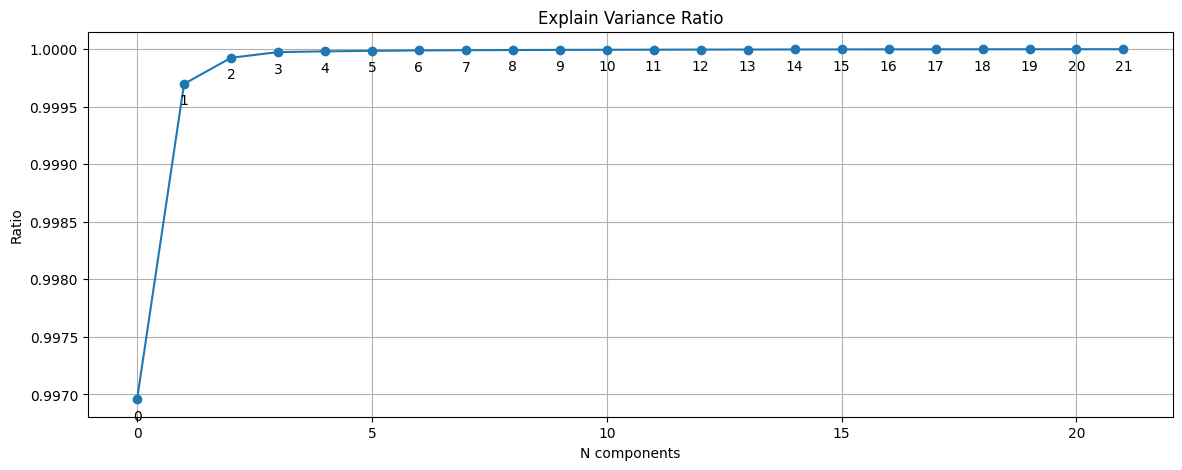

In [39]:
def explain_variance_ratio(X: pd.DataFrame):
    x_centered = X - X.mean()
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    eigenvalues_sorted = np.sort(eigenvalues)[::-1]
    total = eigenvalues_sorted.sum()
    
    return eigenvalues_sorted / total

evr = explain_variance_ratio(X)
cumsum = np.cumsum(evr)

plt.figure(figsize=(14, 5))
plt.plot(cumsum, marker="o")
plt.title("Explain Variance Ratio")
plt.xlabel("N components")
plt.ylabel("Ratio")
plt.grid(True)

for i, y in enumerate(cumsum):
    plt.annotate(str(i), (i, y), textcoords="offset points", xytext=(0, -15), ha='center')

plt.show()

In [47]:
threshold = 0.95
n_components = np.argmax(np.cumsum(evr) >= threshold) + 1
print(f"N components yang di butuhkan untuk menjelaskan {threshold*100}% informasi adalah: {n_components}")

N components yang di butuhkan untuk menjelaskan 95.0% informasi adalah: 1


In [45]:
def pca(X: pd.DataFrame, n_components: int):
    x_centered = X - X.mean()
    cov_matrix = np.cov(x_centered, rowvar=False)
    
    eigenvalues, eigenmatrix = np.linalg.eigh(cov_matrix)
    
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenmatrix_sorted = eigenmatrix[:, sorted_indices]
    
    principal_components = eigenmatrix_sorted[:, :n_components]
    
    # Reduction results
    X_pca = np.dot(x_centered, principal_components)
    return pd.DataFrame(X_pca, index=X.index)

X_train_pca_reduction = pca(X_train, n_components=1)
X_test_pca_reduction = pca(X_test, n_components=1)

X_train_pca_reduction.head(10)

,0
13921,-1078.216464
7198,-819.214605
19668,-504.259807
23515,-370.200538
14322,-195.238564
4877,-68.195926
8508,264.791465
24268,-686.270749
722,1735.797774
20179,318.773721


### Modeling

In [ ]:
class KNN:
    def __init__(self, k: int, p: int, weight, random_state=None):
        self.k = k
        self.p = p
        self.weight = weight
        self.random_state = random_state

    def fit(self, X_train: pd.DataFrame, y_train: pd.DataFrame):
        self.X_train = X_train.to_numpy()
        self.y_train = y_train.to_numpy()

    def _minkowski_distance(self, a, b):
        return np.power(np.sum(np.abs(a - b) ** self.p, axis=0), 1 / self.p)

    def _get_nn(self, X_test: pd.DataFrame):
        distances = self._minkowski_distance(X_test, self.X_train)
        k_idxs = np.argsort(distances)[:self.k]
        k_labels = [self.y_train[i] for i in k_idxs]
        k_distances = [distances[i] for i in k_idxs]

        if self.weight == "uniform":
            values, counts = np.unique(k_labels, return_counts=True)
            max_count = max(counts)
            candidates = values[counts == max_count]
            return np.random.choice(candidates)

        elif self.weight == "distance":
            weights = [(1 / (d + 1e-5)) for d in k_distances]

        elif callable(self.weight):
            weights = [self.weight(d) for d in k_distances]

        label_weight = dict()
        for label, weight in zip(k_labels, weights):
            label_weight[label] = label_weight.get(label, 0) + weight

        max_weight = max(label_weight.values())
        candidates = [
            label for label, weight in label_weight.items() if weight == max_weight
        ]

        return np.random.choice(candidates)

    def predict(self, X_test: pd.DataFrame):
        return np.array([self._get_nn(x) for x in X_test.to_numpy()])

### Evaluation Model

In [ ]:
class EvaluationModel:
    def __init__(self, y_true: pd.DataFrame, y_pred: np.ndarray):
        self.y_true = y_true
        self.y_pred = y_pred

    def accuracy(self):
        return np.sum(self.y_true == self.y_pred) / len(self.y_true)

    def precision(self, TP, FP):
        return TP / (TP + FP) if (TP + FP) != 0 else 0

    def recall(self, TP, FN):
        return TP / (TP + FN) if (TP + FN) != 0 else 0

    def f1_score(self, TP, FP, FN):
        P = self.precision(TP, FP)
        R = self.recall(TP, FN)

        return 2 * (P * R) / (P + R) if (P + R) != 0 else 0

    def macro_avg(self, result_df: pd.DataFrame):
        return result_df[["Precision", "Recall", "F1-Score"]].mean()

    def weighted_avg(self, result_df: pd.DataFrame):
        weights = np.bincount(self.y_true)
        total = weights.sum()

        return (
            result_df[["Precision", "Recall", "F1-Score"]].T
            * weights
            / total
        ).T.sum()

    def make_report(self):
        cats = np.unique(self.y_true)

        report_dict = {"Category": [], "Precision": [], "Recall": [], "F1-Score": []}

        for cat in cats:
            # Confusion Matrix
            TP = np.sum(
                (self.y_true == cat) & (self.y_pred == cat)
            )  # Asli POSITIF prediksi POSITIF
            TN = np.sum(
                (self.y_true != cat) & (self.y_pred != cat)
            )  # Asli NEGATIF prediksi NEGATIF
            FP = np.sum(
                (self.y_true != cat) & (self.y_pred == cat)
            )  # Asli NEGATIF prediksi POSITIF
            FN = np.sum(
                (self.y_true == cat) & (self.y_pred != cat)
            )  # Asli POSITIF prediksi NEGATIF

            # Calculation Matrix
            P = self.precision(TP, FP)
            R = self.recall(TP, FN)
            F1 = self.f1_score(TP, FP, FN)

            # Append Matrix
            report_dict["Category"].append(cat)
            report_dict["Precision"].append(P)
            report_dict["Recall"].append(R)
            report_dict["F1-Score"].append(F1)

        accuracy = self.accuracy()

        result_df = pd.DataFrame(report_dict)

        macro_avg = self.macro_avg(result_df)
        weighted_avg = self.weighted_avg(result_df)

        summary_record = pd.DataFrame.from_records(
            [
                {"Category": "macro avg", **macro_avg},
                {"Category": "weighted avg", **weighted_avg},
            ]
        )

        final_result_df = pd.concat([result_df, summary_record], ignore_index=True)

        return final_result_df, accuracy

### Grid Search CV Hypertunning parameter

In [ ]:
def log_report(params, index, total):
    separator = "=" * 100
    progress_text = f"[{index}/{total}] [{index / total*100:.2f}%]"

    print(separator)
    print(progress_text)
    print(params)
    print(separator)


def search_best_model(params: dict, limit_sample=None):
    total_loop = (
        len(params["K"]) *
        len(params["P"]) *
        len(params["weight"]) *
        len(params["random_state"]) *
        len(params["Scaler"])
    )
    
    count = 1
    
    results = list()

    for K in params["K"]:
        for P in params["P"]:
            for weight in params["weight"]:
                for random_state in params["random_state"]:
                    for i, (train, test) in enumerate(params["Scaler"]):
                        # Initialization model
                        model = KNN(k=K, p=P, random_state=random_state, weight=weight)
                        model.fit(
                            X_train=train[:limit_sample], y_train=y_train[:limit_sample]
                        )

                        preds = model.predict(X_test=test[:limit_sample])

                        # Evaluation model
                        eval_model = EvaluationModel(
                            y_true=y_test[:limit_sample], y_pred=preds
                        )
                        report_df, accuracy = eval_model.make_report()


                        # Append params
                        param_results = {
                            "K": K,
                            "P": P,
                            "weight": weight,
                            "random_state": random_state,
                            "Scaler": i,
                        }
                        
                        results.append(
                            {
                                "report_df": report_df,
                                "accuracy": accuracy,
                                "params": param_results,
                            }
                        )
                        
                        # Looging
                        log_report(param_results, count, total_loop)
                        count += 1

    return results

In [ ]:
from IPython.display import display

def custom_distance(d):
    return 1 / (d**2 + 1e-5)


params = {
    "K": range(1, 9),
    "P": range(1, 5),
    "weight": ["uniform", "distance", custom_distance],
    "random_state": [0, 44, 99],
    "Scaler": [
        (X_train_mm_scaler, X_test_mm_scaler),
        (X_train_std_scaler, X_test_std_scaler),
        (X_train, X_test),
    ],
}

results = search_best_model(params, limit_sample=300)

sorted_results = sorted(results, key=lambda x: x["accuracy"], reverse=True)[:5]

for row in sorted_results:
    print(f"Params: {row['params']}")
    display(row["report_df"])
    print(f"Accuracy: {row['accuracy']}")

[1/864] [0.12%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 0, 'Scaler': 0}
[2/864] [0.23%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 0, 'Scaler': 1}
[3/864] [0.35%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 0, 'Scaler': 2}
[4/864] [0.46%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 44, 'Scaler': 0}
[5/864] [0.58%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 44, 'Scaler': 1}
[6/864] [0.69%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 44, 'Scaler': 2}
[7/864] [0.81%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 99, 'Scaler': 0}
[8/864] [0.93%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 99, 'Scaler': 1}
[9/864] [1.04%]
{'K': 1, 'P': 1, 'weight': 'uniform', 'random_state': 99, 'Scaler': 2}
[10/864] [1.16%]
{'K': 1, 'P': 1, 'weight': 'distance', 'random_state': 0, 'Scaler': 0}
[11/864] [1.27%]
{'K': 1, 'P': 1, 'weight': 'distance', 'random_state': 0, 'Scaler': 1}
[12/864] [1.39%]
{'K': 1, 'P': 1, 'weight': 

,Category,Precision,Recall,F1-Score
0,0,0.711111,0.240602,0.359551
1,1,0.603922,0.922156,0.729858
2,macro avg,0.657516,0.581379,0.544704
3,weighted avg,0.651442,0.620000,0.565688


Accuracy: 0.62
Params: {'K': 6, 'P': 3, 'weight': 'uniform', 'random_state': 99, 'Scaler': 0}


,Category,Precision,Recall,F1-Score
0,0,0.720930,0.233083,0.352273
1,1,0.603113,0.928144,0.731132
2,macro avg,0.662022,0.580613,0.541702
3,weighted avg,0.655345,0.620000,0.563171


Accuracy: 0.62
Params: {'K': 6, 'P': 3, 'weight': 'uniform', 'random_state': 44, 'Scaler': 0}


...

Accuracy: 0.6166666666666667
Params: {'K': 6, 'P': 3, 'weight': 'uniform', 'random_state': 0, 'Scaler': 1}


,Category,Precision,Recall,F1-Score
0,0,0.660377,0.263158,0.376344
1,1,0.603239,0.892216,0.719807
2,macro avg,0.631808,0.577687,0.548075
3,weighted avg,0.628570,0.613333,0.567538


Accuracy: 0.6133333333333333
Params: {'K': 6, 'P': 3, 'weight': 'uniform', 'random_state': 99, 'Scaler': 1}


,Category,Precision,Recall,F1-Score
0,0,0.666667,0.255639,0.369565
1,1,0.602410,0.898204,0.721154
2,macro avg,0.634538,0.576921,0.545360
3,weighted avg,0.630897,0.613333,0.565283


Accuracy: 0.6133333333333333
